# Median Per-Cell QC by Platform and Segmentation

Load AnnData tables embedded in MerXen `latest_spatialdata.zarr` outputs, compute per-cell transcript and detected-gene counts from each table's `X` matrix, remove low-count cells, and plot paired MERSCOPE/Xenium medians.

In [5]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [6]:
def find_repo_root() -> Path:
    """Find the MerXen repository from either repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find a repo root containing README.md and results/.")


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
FIGURE_PATH = REPO_ROOT / "notebooks" / "median_cell_qc_by_platform_segmentation.png"

# Leave as None to use every result. Set to e.g. ["P5011"] while iterating.
SAMPLE_IDS = None

# Cells with 0 or 1 detected genes or transcripts are removed before medians.
MIN_COUNT_EXCLUSIVE = 1

REPO_ROOT, RESULTS_DIR

(PosixPath('/home/becalia/code/MerXen'),
 PosixPath('/home/becalia/code/MerXen/results'))

In [7]:
SEGMENTATION_STYLES = {
    "original_seg": {
        "table_key": "table_original",
        "label": "Out of instrument segmentation",
        "color": "black",
        "offset": -0.035,
    },
    "reseg": {
        "table_key": "table_MOSAIK_proseg",
        "label": "Optimised resegmentation",
        "color": "#d62728",
        "offset": 0.035,
    },
}

PLATFORM_X = {"merscope": 0.0, "xenium": 1.0}
PLATFORM_LABELS = {"merscope": "MERSCOPE", "xenium": "Xenium"}


def discover_spatialdata_outputs(results_dir: Path) -> pd.DataFrame:
    """Find latest SpatialData zarrs without loading their arrays."""
    rows = []
    for zarr_path in sorted(results_dir.glob("*/*/latest/latest_spatialdata.zarr")):
        pair_id, platform = zarr_path.relative_to(results_dir).parts[:2]
        if platform not in PLATFORM_X:
            continue
        if SAMPLE_IDS is not None and pair_id not in SAMPLE_IDS:
            continue
        rows.append({"pair_id": pair_id, "platform": platform, "zarr_path": zarr_path})

    if not rows:
        raise FileNotFoundError(f"No latest_spatialdata.zarr outputs found below {results_dir}.")
    return pd.DataFrame(rows)


spatialdata_outputs = discover_spatialdata_outputs(RESULTS_DIR)
display(spatialdata_outputs.assign(zarr_path=lambda df: df["zarr_path"].map(lambda p: p.relative_to(REPO_ROOT))))

,pair_id,platform,zarr_path
0,P1212,merscope,results/P1212/merscope/latest/latest_spatialda...
1,P1212,xenium,results/P1212/xenium/latest/latest_spatialdata...
2,P5011,merscope,results/P5011/merscope/latest/latest_spatialda...
3,P5011,xenium,results/P5011/xenium/latest/latest_spatialdata...
4,P7113,merscope,results/P7113/merscope/latest/latest_spatialda...
5,P7113,xenium,results/P7113/xenium/latest/latest_spatialdata...
6,P7113_IF,merscope,results/P7113_IF/merscope/latest/latest_spatia...
7,P7513,merscope,results/P7513/merscope/latest/latest_spatialda...
8,P7513,xenium,results/P7513/xenium/latest/latest_spatialdata...
9,P7513_IF,merscope,results/P7513_IF/merscope/latest/latest_spatia...


In [11]:
import spatialdata as sd
p7513_zarr = sd.read_zarr(REPO_ROOT / "results" / "P7513" / "merscope" / "latest" / "latest_spatialdata.zarr")

In [48]:
#plt.hist(p7513_zarr.tables["table_MOSAIK_proseg"].X.sum(axis=1), bins=50, range=(0, 500))
np.median(p7513_zarr.tables["table_MOSAIK_proseg"].X.sum(axis=0).flatten().tolist()[0])

np.float64(5632.5)

In [49]:
p7513_zarr.tables

{'table': AnnData object with n_obs × n_vars = 231666 × 350
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region'
    var: 'gene', 'total_count', 'lambda_bg_0', 'lambda_bg_1', 'lambda_bg_2', 'lambda_bg_3', 'lambda_bg_4', 'lambda_bg_5', 'lambda_bg_6'
    uns: 'proseg_run', 'spatialdata_attrs'
    obsm: 'spatial'
    obsp: 'transition_counts', 'table_cell_boundaries': AnnData object with n_obs × n_vars = 231666 × 350
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region'
    var: 'gene', 'total_count', 'lambda_bg_0', 'lambda_bg_1', 'lambda_bg_2', 'lambda_bg_3', 'lambda_bg_4', 'lambda_bg_5', 'lambda_bg_6'
    uns: 'proseg_run', 'spatialdata_attrs'
    obsm: 'spatial'
    obsp: 'transition_counts', 'table_cell_boundaries_aligned_nonrigid': AnnData object with n_obs × n_vars = 231666 × 350
    obs: 'cell_id', 'region'
    var: 'ge

In [8]:
def matrix_row_sums(matrix) -> np.ndarray:
    """Return per-cell transcript counts from an AnnData X matrix."""
    return np.asarray(matrix.sum(axis=1)).ravel()


def matrix_nonzero_by_row(matrix) -> np.ndarray:
    """Return per-cell detected-gene counts from an AnnData X matrix."""
    if sparse.issparse(matrix):
        return np.diff(matrix.tocsr().indptr)
    return np.asarray((matrix > 0).sum(axis=1)).ravel()


def compute_table_medians(zarr_path: Path, table_key: str) -> dict[str, float | int | str]:
    """Load one AnnData table from a SpatialData zarr and compute filtered medians."""
    table_path = zarr_path / "tables" / table_key
    if not table_path.exists():
        raise FileNotFoundError(f"Missing table {table_key!r} in {zarr_path}")

    adata = ad.read_zarr(table_path)
    transcript_counts = matrix_row_sums(adata.X)
    gene_counts = matrix_nonzero_by_row(adata.X)

    keep_cells = (transcript_counts > MIN_COUNT_EXCLUSIVE) & (gene_counts > MIN_COUNT_EXCLUSIVE)
    if not np.any(keep_cells):
        raise ValueError(f"No cells passed the >{MIN_COUNT_EXCLUSIVE} count filter for {table_path}")

    return {
        "table_key": table_key,
        "n_cells": int(adata.n_obs),
        "n_cells_after_filter": int(keep_cells.sum()),
        "n_cells_removed": int((~keep_cells).sum()),
        "median_genes_per_cell": float(np.median(gene_counts[keep_cells])),
        "median_transcripts_per_cell": float(np.median(transcript_counts[keep_cells])),
    }


def compute_all_medians(spatialdata_outputs: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for output in spatialdata_outputs.itertuples(index=False):
        for segmentation, style in SEGMENTATION_STYLES.items():
            table_path = output.zarr_path / "tables" / style["table_key"]
            if not table_path.exists():
                continue
            metrics = compute_table_medians(output.zarr_path, style["table_key"])
            rows.append({
                "pair_id": output.pair_id,
                "platform": output.platform,
                "segmentation": segmentation,
                "zarr_path": str(output.zarr_path.relative_to(REPO_ROOT)),
                **metrics,
            })

    if not rows:
        raise FileNotFoundError("No requested AnnData tables were found in the SpatialData outputs.")
    return pd.DataFrame(rows).sort_values(["pair_id", "segmentation", "platform"]).reset_index(drop=True)


metrics = compute_all_medians(spatialdata_outputs)
display(metrics)

,pair_id,platform,segmentation,zarr_path,table_key,n_cells,n_cells_after_filter,n_cells_removed,median_genes_per_cell,median_transcripts_per_cell
0,P1212,merscope,original_seg,results/P1212/merscope/latest/latest_spatialda...,table_original,280916,249003,31913,8.0,9.0
1,P1212,xenium,original_seg,results/P1212/xenium/latest/latest_spatialdata...,table_original,263209,239377,23832,10.0,14.0
2,P1212,merscope,reseg,results/P1212/merscope/latest/latest_spatialda...,table_MOSAIK_proseg,324633,58737,265896,3.0,6.0
3,P1212,xenium,reseg,results/P1212/xenium/latest/latest_spatialdata...,table_MOSAIK_proseg,275807,103993,171814,9.0,17.0
4,P5011,merscope,original_seg,results/P5011/merscope/latest/latest_spatialda...,table_original,230546,167402,63144,7.0,8.0
5,P5011,xenium,original_seg,results/P5011/xenium/latest/latest_spatialdata...,table_original,213403,185798,27605,9.0,13.0
6,P5011,merscope,reseg,results/P5011/merscope/latest/latest_spatialda...,table_MOSAIK_proseg,281572,13191,268381,2.0,6.0
7,P5011,xenium,reseg,results/P5011/xenium/latest/latest_spatialdata...,table_MOSAIK_proseg,239166,94736,144430,8.0,18.0
8,P7113,merscope,original_seg,results/P7113/merscope/latest/latest_spatialda...,table_original,158350,156214,2136,14.0,21.0
9,P7113,xenium,original_seg,results/P7113/xenium/latest/latest_spatialdata...,table_original,218280,210704,7576,14.0,20.0


PosixPath('/home/becalia/code/MerXen/notebooks/median_cell_qc_by_platform_segmentation.png')

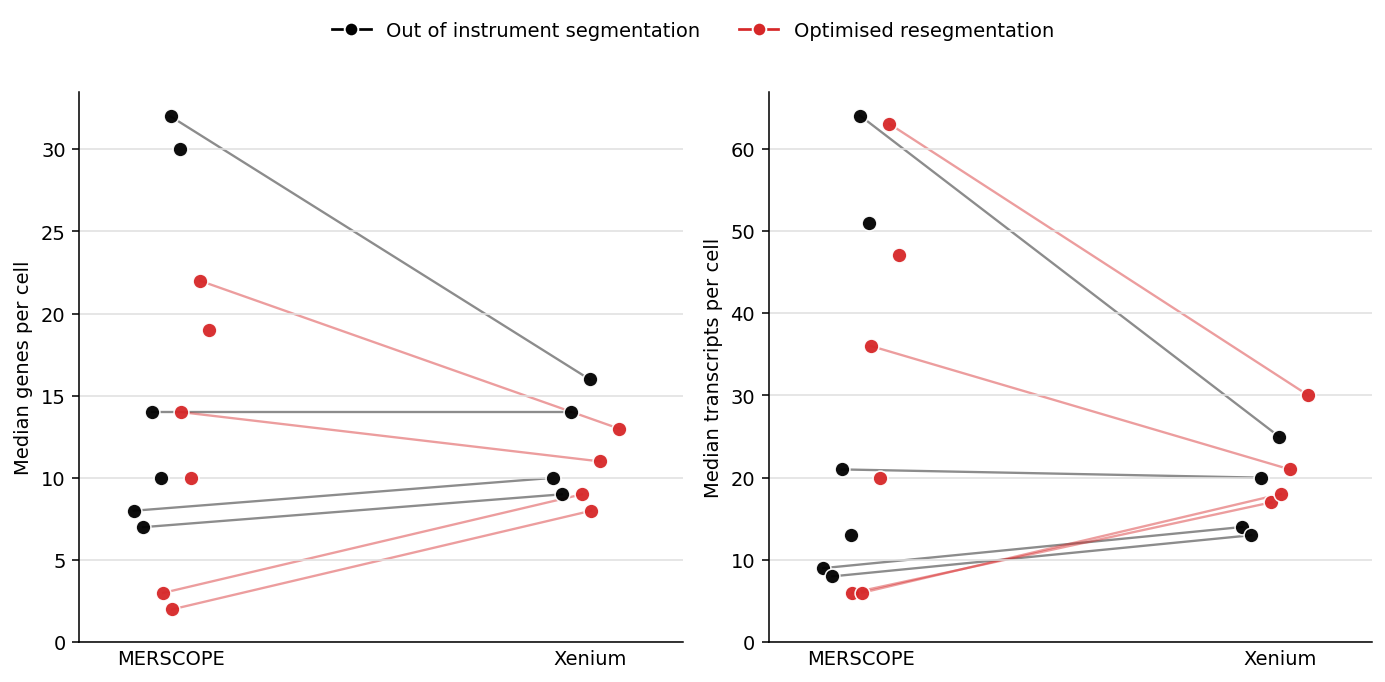

In [9]:
def sample_jitter(metrics: pd.DataFrame, width: float = 0.055) -> dict[str, float]:
    """Small deterministic x offsets so overlapping sample points remain visible."""
    sample_ids = sorted(metrics["pair_id"].unique())
    if len(sample_ids) == 1:
        return {sample_ids[0]: 0.0}
    return dict(zip(sample_ids, np.linspace(-width, width, len(sample_ids)), strict=True))


JITTER = sample_jitter(metrics)


def x_position(pair_id: str, platform: str, segmentation: str) -> float:
    return PLATFORM_X[platform] + SEGMENTATION_STYLES[segmentation]["offset"] + JITTER[pair_id]


def plot_metric_panel(ax: plt.Axes, metric_column: str, ylabel: str) -> None:
    for segmentation, style in SEGMENTATION_STYLES.items():
        seg_df = metrics.loc[metrics["segmentation"] == segmentation].copy()

        for pair_id, sample_df in seg_df.groupby("pair_id", sort=True):
            platform_df = sample_df.set_index("platform")
            if {"merscope", "xenium"}.issubset(platform_df.index):
                xs = [
                    x_position(pair_id, "merscope", segmentation),
                    x_position(pair_id, "xenium", segmentation),
                ]
                ys = [
                    platform_df.loc["merscope", metric_column],
                    platform_df.loc["xenium", metric_column],
                ]
                ax.plot(xs, ys, color=style["color"], linewidth=1.2, alpha=0.45, zorder=1)

        xs = [x_position(row.pair_id, row.platform, row.segmentation) for row in seg_df.itertuples()]
        ax.scatter(
            xs,
            seg_df[metric_column],
            s=58,
            marker="o",
            color=style["color"],
            edgecolors="white",
            linewidths=0.8,
            alpha=0.95,
            zorder=3,
        )

    ax.set_xticks([PLATFORM_X["merscope"], PLATFORM_X["xenium"]])
    ax.set_xticklabels([PLATFORM_LABELS["merscope"], PLATFORM_LABELS["xenium"]])
    ax.set_xlim(-0.22, 1.22)
    ax.set_ylim(bottom=0)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="0.88", linewidth=0.8)
    ax.tick_params(axis="x", length=0)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True)

plot_metric_panel(axes[0], "median_genes_per_cell", "Median genes per cell")
plot_metric_panel(axes[1], "median_transcripts_per_cell", "Median transcripts per cell")

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color=style["color"],
        markerfacecolor=style["color"],
        markeredgecolor="white",
        markersize=7,
        linewidth=1.4,
        label=style["label"],
    )
    for style in SEGMENTATION_STYLES.values()
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.92))

fig.savefig(FIGURE_PATH, bbox_inches="tight")
FIGURE_PATH